In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [43]:
ads = pd.read_csv("Social_Network_Ads.csv")
ads

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0
...,...,...,...,...,...
395,15691863,Female,46.0,41000.0,1
396,15706071,Male,51.0,23000.0,1
397,15654296,Female,50.0,20000.0,1
398,15755018,Male,36.0,33000.0,0


In [44]:
# univariate analysis

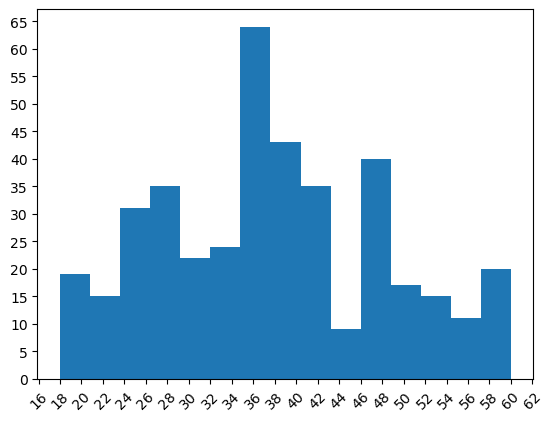

In [45]:

plt.xticks(range(0,70,2), rotation = 45 )
plt.yticks(range(0,80,5))
plt.hist(ads['Age'],bins = 15 );

In [46]:
# outlier detection

In [47]:
ads

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0
...,...,...,...,...,...
395,15691863,Female,46.0,41000.0,1
396,15706071,Male,51.0,23000.0,1
397,15654296,Female,50.0,20000.0,1
398,15755018,Male,36.0,33000.0,0


In [48]:
# for the age col, on put the following values at that index

# 2->8,3->85

In [49]:
ads.loc[2, 'Age'] = 5
ads.loc[3, 'Age'] = 85

In [50]:
ads

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,5.0,43000.0,0
3,15603246,Female,85.0,57000.0,0
4,15804002,Male,19.0,76000.0,0
...,...,...,...,...,...
395,15691863,Female,46.0,41000.0,1
396,15706071,Male,51.0,23000.0,1
397,15654296,Female,50.0,20000.0,1
398,15755018,Male,36.0,33000.0,0


In [51]:
"""loc is used to access data using row labels and column names, whereas iloc is used
to access data using row numbers and column numbers.""";

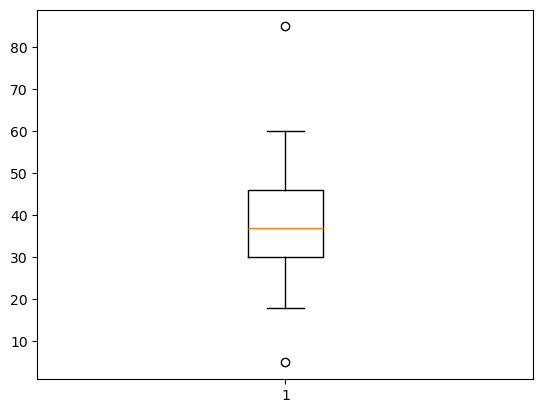

In [52]:
plt.boxplot(ads['Age']);

In [53]:
def remove_outliers(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    outliers = df[(df[col] < LB) | (df[col] > UB)]

    print("Outliers are:")
    print(outliers)

    return df[(df[col] >= LB) & (df[col] <= UB)]

In [54]:
ads = remove_outliers(ads, 'Age')

Outliers are:
    User ID  Gender   Age  EstimatedSalary  Purchased
2  15668575  Female   5.0          43000.0          0
3  15603246  Female  85.0          57000.0          0


In [55]:
ads

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
4,15804002,Male,19.0,76000.0,0
5,15728773,Male,27.0,58000.0,0
6,15598044,Female,27.0,84000.0,0
...,...,...,...,...,...
395,15691863,Female,46.0,41000.0,1
396,15706071,Male,51.0,23000.0,1
397,15654296,Female,50.0,20000.0,1
398,15755018,Male,36.0,33000.0,0


In [ ]:
# practice =>
# load the tips dataset from seaborn
# do detailed EDA(charts along with explaination of what we r understanding from them)
# u can use official documentation for ref

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')

tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [58]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [59]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


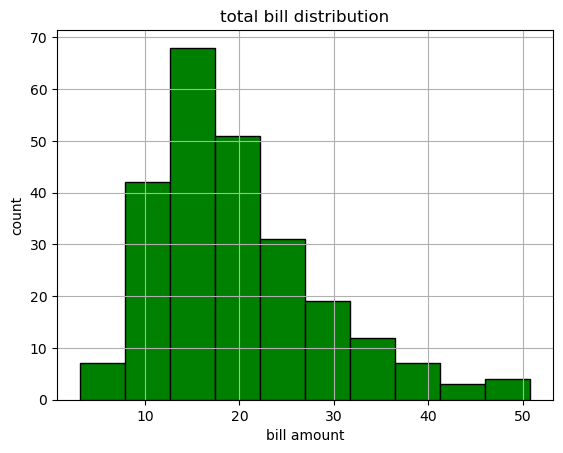

In [84]:
# 1. HIST
plt.title("total bill distribution")
plt.xlabel("bill amount")
plt.ylabel("count")
plt.hist(tips['total_bill'], color='green', edgecolor='black')
plt.grid()

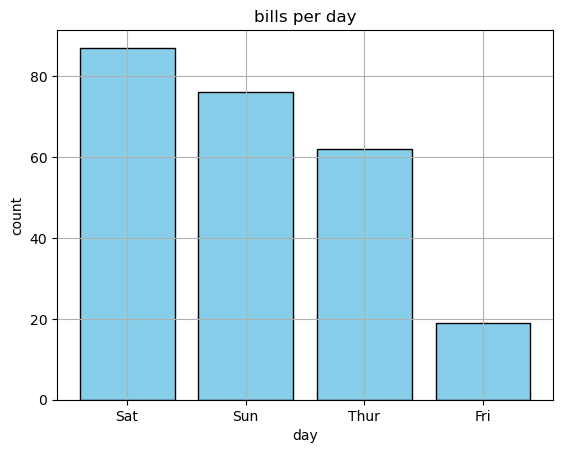

In [81]:
# 2. BAR - avg tip by day
day = tips['day'].value_counts().index
count = tips['day'].value_counts().values
plt.title("bills per day")
plt.xlabel("day")
plt.ylabel("count")
plt.bar(day, count, color='skyblue', edgecolor='black')
plt.grid()
plt.show()

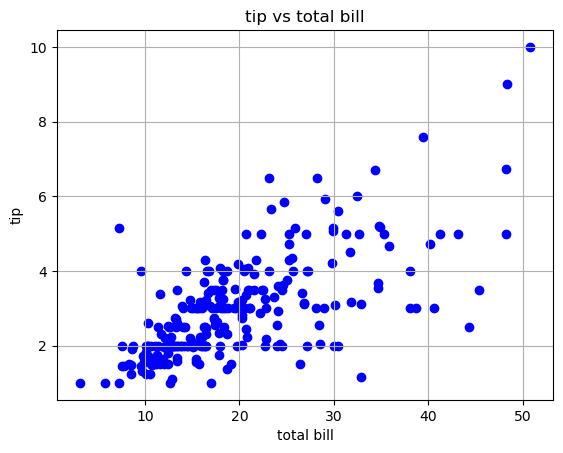

In [82]:
# 3. SCATTER
plt.title("tip vs total bill")
plt.xlabel("total bill")
plt.ylabel("tip")
plt.scatter(tips['total_bill'], tips['tip'], color='blue')
plt.grid()
plt.show()


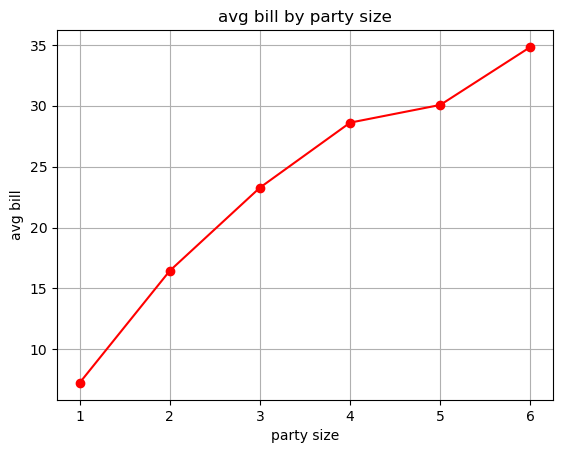

In [83]:
# 4. LINE CHART - avg bill by size
size = [1,2,3,4,5,6]
avg_bill = tips.groupby('size')['total_bill'].mean()
plt.title("avg bill by party size")
plt.xlabel("party size")
plt.ylabel("avg bill")
plt.plot(size, avg_bill, color='red', marker='o')
plt.grid()
plt.show()